# FIG CESM run evaluations

In [2]:
import os
import sys
import yaml
import argparse
import pandas as pd
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [3]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [4]:
import matplotlib.transforms as mtransforms

In [5]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [6]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [7]:
from numpy.lib.stride_tricks import sliding_window_view

def moving_average_axis(a, window, axis=-1, pad_mode="reflect"):
    a = np.asarray(a, dtype=float)
    if window < 1:
        raise ValueError("window must be >= 1")

    # Asymmetric split works for even/odd windows
    pad_left = (window - 1) // 2
    pad_right = window // 2

    # Build pad widths for all axes; pad only along the chosen axis
    pad_widths = [(0, 0)] * a.ndim
    pad_widths[axis] = (pad_left, pad_right)

    apad = np.pad(a, pad_widths, mode=pad_mode)

    # Sliding windows along `axis`, then NaN-aware average over window dim
    sw = sliding_window_view(apad, window_shape=window, axis=axis)
    return np.nanmean(sw, axis=-1)

from collections import defaultdict

def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals into disjoint union."""
    if not intervals:
        return []
    sorted_ivs = sorted(intervals, key=lambda x: x[0])
    merged = [list(sorted_ivs[0])]
    for start, end in sorted_ivs[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return merged


In [8]:
model_names = ['target', 'era5', 'gdas', 'unet',]
varnames = ['WRF_PWAT', 'WRF_T2', 'WRF_precip', 'WRF_SPD10']

In [9]:
PLOT_lines_full = {}

list_ds_scores = []
for year in range(2020, 2025):
    zarr_path = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verification/TC_verification_scores_{year}.zarr'
    ds_ = xr.open_zarr(zarr_path)
    list_ds_scores.append(ds_)

ds_combined = xr.combine_by_coords(list_ds_scores)

for var_ in varnames:
    for model_ in ['era5', 'gdas', 'unet']:
        if model_ == 'unet':
            mae_ = ds_combined['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
            PLOT_lines_full[f'mae_{var_}_{model_}'] = mae_
        else:
            mae_ = ds_combined['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
            PLOT_lines_full[f'mae_{var_}_{model_}'] = mae_

PLOT_lines = {}
for year in range(2020, 2025):
    fn_ = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verification/TC_verification_scores_{year}.zarr'
    ds_scores = xr.open_zarr(fn_)
    PLOT_lines[f'year_{year}'] = ds_scores['time'].values
    
    for var_ in varnames:
        for model_ in ['era5', 'gdas', 'unet']:
            if model_ == 'unet':
                mae_ = ds_scores['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_lines[f'mae_{var_}_{model_}_{year}'] = moving_average_axis(mae_, 30*24, axis=0)
            else:
                mae_ = ds_scores['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_lines[f'mae_{var_}_{model_}_{year}'] = moving_average_axis(mae_, 30*24, axis=0)

In [10]:
raw_cases = [
    # season, hurdat_id, storm, category, track_start, track_end
    (2020, "AL082020", "Hanna",    1, "2020-07-23 00:00", "2020-07-26 00:00"),
    (2020, "AL092020", "Isaias",   1, "2020-07-31 06:00", "2020-08-04 18:00"),
    (2020, "AL142020", "Marco",    1, "2020-08-22 12:00", "2020-08-25 00:00"),
    (2020, "AL132020", "Laura",    4, "2020-08-24 02:00", "2020-08-29 00:00"),
    (2020, "AL192020", "Sally",    2, "2020-09-11 18:00", "2020-09-17 06:00"),
    (2020, "AL252020", "Gamma",    1, "2020-10-03 16:45", "2020-10-06 12:00"),
    (2020, "AL262020", "Delta",    3, "2020-10-07 06:00", "2020-10-10 12:00"),
    (2020, "AL282020", "Zeta",     3, "2020-10-27 03:55", "2020-10-29 12:00"),
    (2020, "AL292020", "Eta",      1, "2020-11-08 00:00", "2020-11-13 06:00"),

    (2021, "AL052021", "Elsa",     1, "2021-07-05 00:00", "2021-07-09 16:30"),
    (2021, "AL082021", "Henri",    1, "2021-08-18 18:00", "2021-08-23 12:00"),
    #(2021, "AL072021", "Grace",    3, "2021-08-19 09:45", "2021-08-21 12:00"),
    (2021, "AL092021", "Ida",      4, "2021-08-27 12:00", "2021-09-01 06:00"),
    (2021, "AL142021", "Nicholas", 1, "2021-09-12 12:00", "2021-09-15 12:00"),

    #(2022, "AL072022", "Fiona",    4, "2022-09-20 00:00", "2022-09-23 06:00"),
    (2022, "AL092022", "Ian",      5, "2022-09-27 00:00", "2022-09-30 18:05"),
    (2022, "AL172022", "Nicole",   1, "2022-11-07 06:00", "2022-11-11 12:00"),

    #(2023, "AL082023", "Franklin", 4, "2023-08-24 00:00", "2023-08-30 12:00"),
    (2023, "AL102023", "Idalia",   4, "2023-08-26 12:00", "2023-08-31 06:00"),
    #(2023, "AL132023", "Lee",      2, "2023-09-13 12:00", "2023-09-15 12:00"),

    (2024, "AL022024", "Beryl",    1, "2024-07-05 11:00", "2024-07-09 06:00"),
    (2024, "AL042024", "Debby",    1, "2024-08-03 00:00", "2024-08-08 18:00"),
    #(2024, "AL052024", "Ernesto",  2, "2024-08-14 18:00", "2024-08-16 06:00"),
    (2024, "AL062024", "Franc.",  2, "2024-09-09 12:00", "2024-09-12 12:00"),
    (2024, "AL092024", "Helene",   4, "2024-09-25 06:00", "2024-09-27 12:00"),
]

TC_names = []
for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    TC_names.append(storm)

In [11]:
raw_cases[18] = (2024, "AL062024", "Francine",  2, "2024-09-09 12:00", "2024-09-12 12:00")

PLOT_HURDAT = {}

for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    ds_TC = xr.open_dataset(f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/tc_track_intensity/{season}_{storm}.nc')
    PLOT_HURDAT[f'{hurdat_id}_time'] = ds_TC['time'].values

In [12]:
IND_TC = {}
for i_year, year in enumerate(range(2020, 2025)):
    for i_case, case in enumerate(raw_cases):
        season, hurdat_id, storm, category, track_start, track_end = case
        if season == year:
            IND_TC[f'{hurdat_id}_{year}'] = [
                np.searchsorted(PLOT_lines[f'year_{year}'], PLOT_HURDAT[f'{hurdat_id}_time'][0],),
                np.searchsorted(PLOT_lines[f'year_{year}'], PLOT_HURDAT[f'{hurdat_id}_time'][-1],),
            ]

In [13]:
yearly_merged = {}
groups = defaultdict(list)

for key, interval in IND_TC.items():
    year = key.split('_')[-1]       # e.g., '2020'
    groups[year].append(interval)

for year in sorted(groups):
    yearly_merged[year] = merge_intervals(groups[year])

In [14]:
my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = my_colors['cyan']
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

In [15]:
line_keys = {}
line_keys['unet'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 3, 'label': ''}
line_keys['era5'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['gdas'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['target'] = {'linewidth': 2.5, 'linestyle': '--', 'color': 'k', 'alpha': 1, 'zorder': 1, 'label': ''}

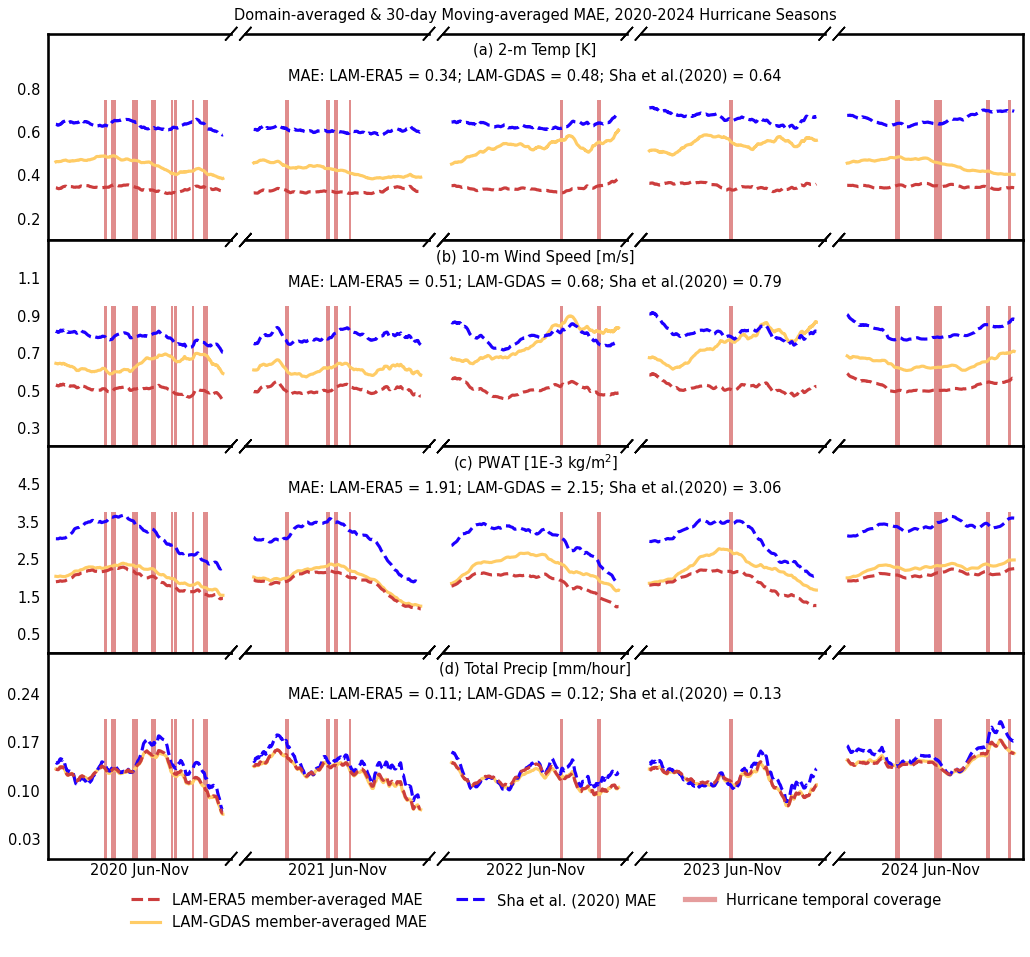

In [16]:
fig = plt.figure(figsize=(13, 11), dpi=dpi_)
gs = gridspec.GridSpec(4, 20, height_ratios=[1, 1, 1, 1,], width_ratios=[1,]*20)

AX_lines0 = []
AX_lines1 = []
AX_lines2 = []
AX_lines3 = []

AX_zes = []
AX_bars = []

for i in range(5):
    AX_lines0.append(plt.subplot(gs[0, 4*i:4*(i+1)]))
    AX_lines1.append(plt.subplot(gs[1, 4*i:4*(i+1)]))
    AX_lines2.append(plt.subplot(gs[2, 4*i:4*(i+1)]))
    AX_lines3.append(plt.subplot(gs[3, 4*i:4*(i+1)]))

AX_lines_all = [AX_lines0, AX_lines1, AX_lines2, AX_lines3]

for ax in AX_lines0 + AX_lines1 + AX_lines2 + AX_lines3:
    ax = gu.ax_decorate_box(ax)

for i in range(4):
    AX_lines_ = AX_lines_all[i]
    AX_lines_[0].spines["right"].set_visible(False)
    AX_lines_[1].spines["left"].set_visible(False)
    AX_lines_[1].spines["right"].set_visible(False)
    AX_lines_[2].spines["left"].set_visible(False)
    AX_lines_[2].spines["right"].set_visible(False)
    AX_lines_[3].spines["left"].set_visible(False)
    AX_lines_[3].spines["right"].set_visible(False)
    AX_lines_[4].spines["left"].set_visible(False)
    AX_lines_[0].tick_params(labelleft=True)

AX_lines_all[3][0].set_xlabel('2020 Jun-Nov', fontsize=14)
AX_lines_all[3][1].set_xlabel('2021 Jun-Nov', fontsize=14)
AX_lines_all[3][2].set_xlabel('2022 Jun-Nov', fontsize=14)
AX_lines_all[3][3].set_xlabel('2023 Jun-Nov', fontsize=14)
AX_lines_all[3][4].set_xlabel('2024 Jun-Nov', fontsize=14)

plt.subplots_adjust(0, 0, 1, 1, hspace=0., wspace=0.4)

xlims = [
    ('2020-06-01', '2020-11-31'), 
    ('2021-06-01', '2021-11-31'), 
    ('2022-06-01', '2022-11-31'), 
    ('2023-06-01', '2023-11-31'), 
    ('2024-06-01', '2024-11-31'), 
]

d = 0.03  # size of break mark in axes coords

YLIM = [
    [0.1, 1.05],
    [0.2, 1.3],
    [0, 5.5],
    [0, 0.3]
]

AX_lines_all[0][0].set_yticks([0.2, 0.4, 0.6, 0.8])
AX_lines_all[1][0].set_yticks([0.3, 0.5, 0.7, 0.9, 1.1])
AX_lines_all[2][0].set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
AX_lines_all[3][0].set_yticks([0.03, 0.1, 0.17, 0.24,])

f = [1, 1, 1e3, 1]
bar_width = [300, 300, 300, 300, 200]
titles = ['(a) 2-m Temp [K]', '(b) 10-m Wind Speed [m/s]', '(c) PWAT [1E-3 kg/m$\mathsf{^2}$]', '(d) Total Precip [mm/hour]']

for i_var, var_ in enumerate(['WRF_T2', 'WRF_SPD10', 'WRF_PWAT', 'WRF_precip']): #  
    title_ = titles[i_var]
    
    for i_year, year in enumerate(range(2020, 2025)):
        w_ = bar_width[i_year]
        bar_pos = [-w_, 0, w_]
        
        for i_model, model_ in enumerate(['era5', 'gdas', 'unet']):
            
            ax_ = AX_lines_all[i_var][i_year]
            trans_ = mtransforms.blended_transform_factory(ax_.transData, ax_.transAxes)
            fake_x = np.arange(len(PLOT_lines[f'year_{year}']))
            
            ax_.plot(fake_x, f[i_var]*PLOT_lines[f'mae_{var_}_{model_}_{year}'], **line_keys[model_])
            ax_.set_ylim(YLIM[i_var])
            
            ivs = yearly_merged[str(year)]
            for start, end in ivs:
                ax_.fill_between(fake_x[start:end+1], 0, 0.68, color=red, linewidth=0, alpha=0.25, transform=trans_)
                
            kwargs = dict(transform=ax_.transAxes, color='k', clip_on=False, linewidth=1.5)
            if i_year in [1, 2, 3, 4]:
                ax_.plot((-d, +d), (-d, +d), **kwargs)       # bottom-left
                ax_.plot((-d, +d), (1 - d, 1 + d), **kwargs) # top-left
            
            # right-side slashes
            if i_year in [0, 1, 2, 3]:
                ax_.plot((1 - d, 1 + d), (-d, +d), **kwargs)       # bottom-right
                ax_.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # top-right

ax_title0 = fig.add_axes([0.0, 0.97, 1, 0.02])
ax_title0.text(0.5, 0.5, titles[0], fontsize=14, va='center', ha='center', transform=ax_title0.transAxes)
era5_ = np.mean(PLOT_lines_full[f'mae_WRF_T2_era5'])
gdas_ = np.mean(PLOT_lines_full[f'mae_WRF_T2_gdas'])
unet_ = np.mean(PLOT_lines_full[f'mae_WRF_T2_unet'])
ax_txt0 = fig.add_axes([0.0, 0.94, 1, 0.02])
ax_txt0.text(
    0.5, 0.5, 
    'MAE: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f}; Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt0.transAxes)

ax_title1 = fig.add_axes([0.0, 0.72, 1, 0.02])
ax_title1.text(0.5, 0.5, titles[1], fontsize=14, va='center', ha='center', transform=ax_title1.transAxes)
era5_ = np.mean(PLOT_lines_full[f'mae_WRF_SPD10_era5'])
gdas_ = np.mean(PLOT_lines_full[f'mae_WRF_SPD10_gdas'])
unet_ = np.mean(PLOT_lines_full[f'mae_WRF_SPD10_unet'])
ax_txt1 = fig.add_axes([0.0, 0.69, 1, 0.02])
ax_txt1.text(
    0.5, 0.5, 
    'MAE: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f}; Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt1.transAxes)

ax_title2 = fig.add_axes([0.0, 0.47, 1, 0.02])
ax_title2.text(0.5, 0.5, titles[2], fontsize=14, va='center', ha='center', transform=ax_title2.transAxes)
era5_ = 1e3*np.mean(PLOT_lines_full[f'mae_WRF_PWAT_era5'])
gdas_ = 1e3*np.mean(PLOT_lines_full[f'mae_WRF_PWAT_gdas'])
unet_ = 1e3*np.mean(PLOT_lines_full[f'mae_WRF_PWAT_unet'])
ax_txt2 = fig.add_axes([0.0, 0.44, 1, 0.02])
ax_txt2.text(
    0.5, 0.5, 
    'MAE: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f}; Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt2.transAxes)

ax_title3 = fig.add_axes([0.0, 0.22, 1, 0.02])
ax_title3.text(0.5, 0.5, titles[3], fontsize=14, va='center', ha='center', transform=ax_title3.transAxes)
era5_ = np.mean(PLOT_lines_full[f'mae_WRF_precip_era5'])
gdas_ = np.mean(PLOT_lines_full[f'mae_WRF_precip_gdas'])
unet_ = np.mean(PLOT_lines_full[f'mae_WRF_precip_unet'])
ax_txt3 = fig.add_axes([0.0, 0.19, 1, 0.02])
ax_txt3.text(
    0.5, 0.5, 
    'MAE: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f}; Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt3.transAxes)

ax_title4 = fig.add_axes([0.0, 1.0125, 1, 0.02])
ax_title4.text(
    0.5, 0.5, 
    'Domain-averaged & 30-day Moving-averaged MAE, 2020-2024 Hurricane Seasons',
    fontsize=14, va='center', ha='center', transform=ax_title4.transAxes
)


handle_legneds1 = []
handle_legneds1.append(mlines.Line2D([], [], **line_keys['era5']))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['gdas']))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['unet']))
handle_legneds1.append(mlines.Line2D([], [], color=red, alpha=0.5, linewidth=5, label=' '))

ax_lg1 = fig.add_axes([0.07, -0.11, 0.86, 0.085])
LG1 = ax_lg1.legend(
    handle_legneds1, [
        'LAM-ERA5 member-averaged MAE', 
        'LAM-GDAS member-averaged MAE', 
        'Sha et al. (2020) MAE', 
        'Hurricane temporal coverage', 
    ], 
    bbox_to_anchor=(1, 1), ncol=3, prop={'size':14}
)

ax_title0.set_axis_off()
ax_title1.set_axis_off()
ax_title2.set_axis_off()
ax_title3.set_axis_off()
ax_title4.set_axis_off()
ax_txt0.set_axis_off()
ax_txt1.set_axis_off()
ax_txt2.set_axis_off()
ax_txt3.set_axis_off()
LG1 = gu.lg_box(LG1)
ax_lg1.set_axis_off()